In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/rtpp_20250907-144043") 
checkpoint_path = checkpoint_dir / "last_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 32, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20250907-144043', 'cuda_id': '0', 'dataset': 'ChuanDian', 'seed': 0, 'minibatch_training': True, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 1.6484907865524292, 'tau_min': 2.3148149921325967e-06, 'tau_max': 32.8729133605957, 'tau_q05': 0.5829246044158936, 'tau_q025': 0.0008729455876164138, 'mag_mean': 3.5779941082000732, 'time_max': 16436.0, 'time_

OptimizedModule(
  (_orig_mod): RecurrentTPP(
    (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
    (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
    (rnn): GRU(2, 32, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

## Loading the catalog

In [4]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.


In [5]:
catalog_ds.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

In [13]:
seq = catalog_ds.full_sequence.to(device)
grid, compensator = model.evaluate_compensator(seq)
g = grid.detach().cpu().numpy()
c = compensator.detach().cpu().numpy()

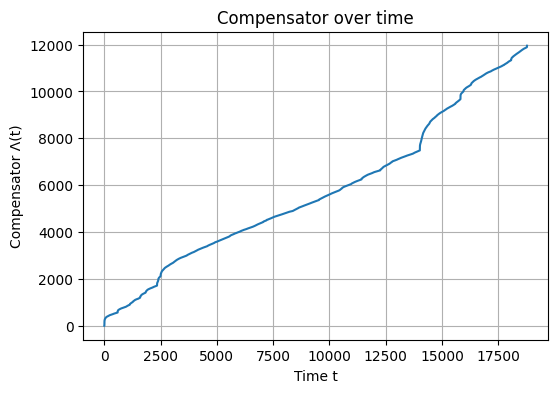

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(g, c)
plt.xlabel("Time t")
plt.ylabel("Compensator Λ(t)")
plt.title("Compensator over time")
plt.grid(True)
plt.show()


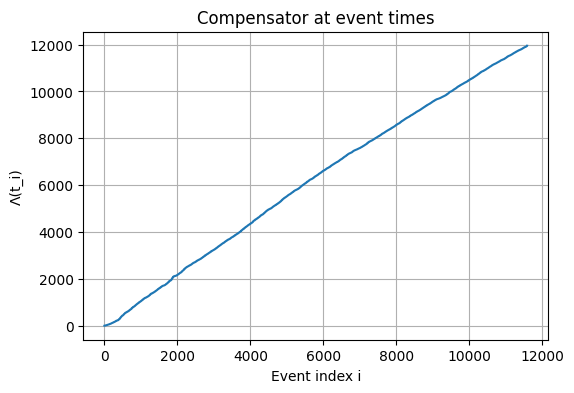

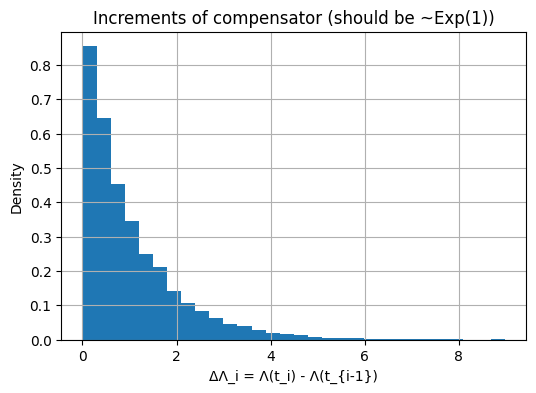

In [ ]:
arrival_times = seq.arrival_times.detach().cpu().numpy()
event_comp = []
for t in arrival_times:
    idx = g.searchsorted(t)  
    event_comp.append(c[idx])
event_comp = np.array(event_comp)

plt.figure(figsize=(6, 4))
plt.step(range(1, len(event_comp) + 1), event_comp, where="post")
plt.xlabel("Event index i")
plt.ylabel("Λ(t_i)")
plt.title("Compensator at event times")
plt.grid(True)
plt.show()

increments = np.diff(event_comp)

plt.figure(figsize=(6, 4))
plt.hist(increments, bins=30, density=True)
plt.xlabel("ΔΛ_i = Λ(t_i) - Λ(t_{i-1})")
plt.ylabel("Density")
plt.title("Increments of compensator (should be ~Exp(1))")
plt.grid(True)
plt.show()
